conda create -n ts-ttm python=3.11 -y

conda activate ts-ttm

pip install "tsfm_public[notebooks] @ git+https://github.com/ibm-granite/granite-tsfm.git@v0.2.18"

pip install scikit-learn matplotlib ipykernel

python -m ipykernel install --user --name ts-ttm --display-name "Python (ts-ttm)"

pip install "transformers>=4.38,<5.0"

In [10]:
# The tsfm-public package on PyPI is broken against modern transformers.
# Install directly from the IBM GitHub repo (v0.2.18 is the last stable tag).
# Run once in your conda env terminal, then restart the kernel:
#
#   pip install "tsfm_public[notebooks] @ git+https://github.com/ibm-granite/granite-tsfm.git@v0.2.18"


# TTM (Tiny Time Mixers) — Model Experiment
**Dataset:** Monthly Labor Market (`monthly_labor_market.csv`)  
**Target:** `EMPLOY`  
**Horizon:** 12 months  
**Split:** 80 % train / last 12 months test  
**Metric:** MAE  
**Model:** TTM pretrained — `ibm-granite/granite-timeseries-ttm-r2`

In [11]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

## 1. Load & Preprocess Data

In [12]:
df = pd.read_csv("../data/processed/monthly_labor_market.csv")

df.rename(columns={"date": "ds"}, inplace=True)
df["ds"] = pd.to_datetime(df["ds"], format="%Y:%m")

df = df.dropna(how="all", subset=df.columns[1:])
df = df.ffill()
df = df.dropna()

df.head()

,ds,POP,LFC,LFPART,RUC,EMPLOY,H,HG,HS
300,1964-01-01,123560.0,72356.0,58.5594,5.6,57487.0,50.8,92.4,39.3
301,1964-02-01,123707.0,72683.0,58.7542,5.4,57753.0,51.5,95.3,39.4
302,1964-03-01,123857.0,72713.0,58.7072,5.4,57897.0,51.5,95.1,39.4
303,1964-04-01,124019.0,73274.0,59.0829,5.3,57922.0,51.7,95.2,39.6
304,1964-05-01,124204.0,73395.0,59.0923,5.1,58089.0,51.9,95.6,39.6


## 2. Train / Test Split

In [13]:
TARGET  = "EMPLOY"
HORIZON = 12
CONTEXT_LEN = 512   # TTM-R2 context length (must match the checkpoint variant)

split = int(len(df) * 0.8)

train_df = df.iloc[:split]
test_df  = df.iloc[split:split + HORIZON]

y_true = test_df[TARGET].values

print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)

Train shape: (596, 9)
Test shape:  (12, 9)


## 3. Load Pretrained TTM

In [14]:
# Import from the correct submodule (not top-level tsfm_public)
from tsfm_public.models.tinytimemixer import TinyTimeMixerForPrediction

ttm = TinyTimeMixerForPrediction.from_pretrained(
    "ibm-granite/granite-timeseries-ttm-r2",
    prediction_filter_length=HORIZON,   # select the 12-step head
)
ttm.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"
ttm = ttm.to(device)

print(f"TTM loaded on {device}.")


TTM loaded on cpu.


## 4. Prepare Context Tensor

In [15]:
series = train_df[TARGET].values.astype(np.float32)

# Use the last CONTEXT_LEN time-steps as context
context = series[-CONTEXT_LEN:]

# TTM expects shape (batch, time, n_channels) — NOT (batch, channels, time)
context_tensor = torch.tensor(context, dtype=torch.float32)
context_tensor = context_tensor.unsqueeze(0).unsqueeze(-1).to(device)  # (1, T, 1)

print("Context tensor shape:", context_tensor.shape)  # should be (1, 512, 1)


Context tensor shape: torch.Size([1, 512, 1])


## 5. Forecast (zero-shot)

In [16]:
with torch.no_grad():
    output = ttm(past_values=context_tensor)

# output.prediction_outputs shape: (batch, horizon, n_channels)
ttm_pred = output.prediction_outputs[0, :HORIZON, 0].cpu().numpy()

print("Shape:     ", ttm_pred.shape)
print("Prediction:", ttm_pred)

Shape:      (12,)
Prediction: [138098.31 137928.53 137846.98 137681.95 137412.84 137313.25 137245.14
 137126.38 136943.95 136669.31 136769.17 136790.77]


## 6. Evaluate — MAE

In [17]:
mae_ttm = mean_absolute_error(y_true, ttm_pred)
print(f"TTM MAE: {mae_ttm:.4f}")

TTM MAE: 1166.0807


## 7. Plot Forecast vs Actual

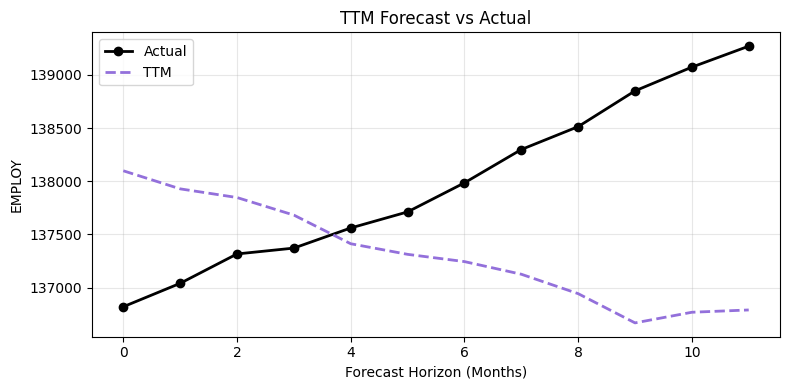


Final MAE — TTM: 1166.0807


In [18]:
t = range(HORIZON)

plt.figure(figsize=(8, 4))

plt.plot(t, y_true,
         color="black", marker="o", label="Actual", linewidth=2)

plt.plot(t, ttm_pred,
         color="mediumpurple", linestyle="--", label="TTM", linewidth=2)

plt.legend()
plt.title("TTM Forecast vs Actual")
plt.xlabel("Forecast Horizon (Months)")
plt.ylabel(TARGET)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nFinal MAE — TTM: {mae_ttm:.4f}")